## PABLO SALVAGNI
### Objetivo:
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las
cámaras digitales modernas. El video a procesar será: “focus_video.mov”.

-------

Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image
Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
- A. Medición sobre todo el frame.
- B. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Para cada experimento se debe presentar:
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto
de máximo enfoque.

##### El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera automática.

------------------- 
#### Puntos extra:
- Aplicar unsharp masking para expandir la zona de enfoque y devolver.

In [78]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

### Funciones 

In [79]:
def area_enfoque( valores_fm, p = 95 ): 
    # Se calcula el valor del percentil
    umbral = np.percentile(valores_fm, p)

    # se buscan frames por encima del umbral
    indices_foco = np.where(np.array(valores_fm) >= umbral)[0]

    if len(indices_foco) > 0:
        inicio = indices_foco[0]
        fin = indices_foco[-1]
        
        # Se grafoca
        plt.figure(figsize=(12, 6))
        plt.plot(valores_fm, label='Métrica FM', color='blue')
        
        # Se sombrea el área de enfoque
        plt.axvspan(inicio, fin, color='green', alpha=0.3, label=f'Zona de Enfoque (Top {100-p}%)')
        
        plt.title(f'Detección de Rango de Enfoque - Percentil {p}')
        plt.xlabel('Frame')
        plt.ylabel('Valor FM')
        plt.legend()
        plt.show()
        
        print(f"El video estuvo en foco entre los frames {inicio} y {fin}")

def area_enfoque_rangos( valores_fm, p = 95 ): 
    # Se calcula el valor del percentil
    umbral = np.percentile(valores_fm, p)

    # se buscan frames por encima del umbral
    indices_foco = np.where(np.array(valores_fm) >= umbral)[0]

    inicio = indices_foco[0]
    fin = indices_foco[-1]
    
    return inicio, fin

# FUNCIONES PARA APLICAR MATRZ DE ENFOQUE CON OPENCV
def calcular_fm(region_gris):
    # Se aplica el algoritmo del paper a una region especifica
    f = np.fft.fft2(region_gris)
    f_shift = np.fft.fftshift(f)
    af = np.abs(f_shift)
    M = np.max(af)
    if M == 0: return 0
    thres = M / 1000
    TH = np.count_nonzero(af > thres)
    return TH / af.size

def aplicar_matriz_enfoque_roi(frame, n, max_fm_global):
    # Primero preparamos las imágenes de trabajo
    img_dibujo = frame.copy()
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    H, W = gris.shape

    # Aquí va tu lógica de ROI centrada
    w_roi = W // 2
    h_roi = H // 2
    x_inicio = (W - w_roi) // 2
    y_inicio = (H - h_roi) // 2

    # El tamaño de cada celda dentro de la ROI
    dx = w_roi // n
    dy = h_roi // n

    for i in range(n):
        for j in range(n):
            y1, y2 = y_inicio + (i * dy), y_inicio + (i + 1) * dy
            x1, x2 = x_inicio + (j * dx), x_inicio + (j + 1) * dx

            celda = gris[y1:y2, x1:x2]
            valor_fm = calcular_fm(celda)

            # Lógica de color
            score = min(valor_fm / max_fm_global, 1.0)
            v, r = int(255 * score), int(255 * (1 - score))
            
            cv2.rectangle(img_dibujo, (x1, y1), (x2, y2), (0, v, r), 2)
            
    return cv2.cvtColor(img_dibujo, cv2.COLOR_BGR2RGB)

def aplicar_matriz_enfoque(frame_original, n_param, max_fm_global):
    # Se segmenta el frame en n x n y dibuja la grilla con colores
    img_dibujo = frame_original.copy()
    gris = cv2.cvtColor(frame_original, cv2.COLOR_BGR2GRAY)
    H, W = gris.shape
    
    # Se define el tamaño dinámico de las celdas
    dy = H // n_param
    dx = W // n_param
    
    for i in range(n_param):
        for j in range(n_param):
            # Se defienen las coordenadas de la celda
            y1, y2 = i * dy, (i + 1) * dy
            x1, x2 = j * dx, (j + 1) * dx
            
            # Se reailiza el cálculo de la métrica en la celda
            celda = gris[y1:y2, x1:x2]
            fm_celda = calcular_fm(celda)
            
            # Se aplica la logica de color para indicar verde el foco, rojo en desenfoque
            # Normalizamos respecto al máximo global para que el color sea relativo al mejor foco posible
            score = min(fm_celda / max_fm_global, 1.0) 
            
            # Color: BGR -> (Azul, Verde, Rojo)
            # Si score es 1 (foco total) -> Verde (0, 255, 0)
            # Si score es 0 (borroso) -> Rojo (0, 0, 255)
            color_verde = int(255 * score)
            color_rojo = int(255 * (1 - score))
            color = (0, color_verde, color_rojo)
            
            # Se dibuja el rectángulo
            cv2.rectangle(img_dibujo, (x1, y1), (x2, y2), color, 4)
            
    return img_dibujo

# FUNCION PARA APLICAR EN VIDEO
def aplicar_unsharp_masking(imagen, k=2.5):
    # Se suaviza la imagen (crear la base para la máscara)
    gauss = cv2.GaussianBlur(imagen, (7, 7), 0.5)
    
    # Se aplicar la suma pesada (Unsharp Masking)
    # La fórmula es: original * (k+1) + gauss * (-k)
    imagen_enfocada = cv2.addWeighted(imagen, k + 1, gauss, -k, 0)
    
    return imagen_enfocada



### 1.A)  Medición sobre todo el frame
Se recorre el video, frame por frame y se calcula el valor maximo de la Transformada de Fourier y se grafica en un histograma donde se puede ver el frame con el valor maximo (en foco)

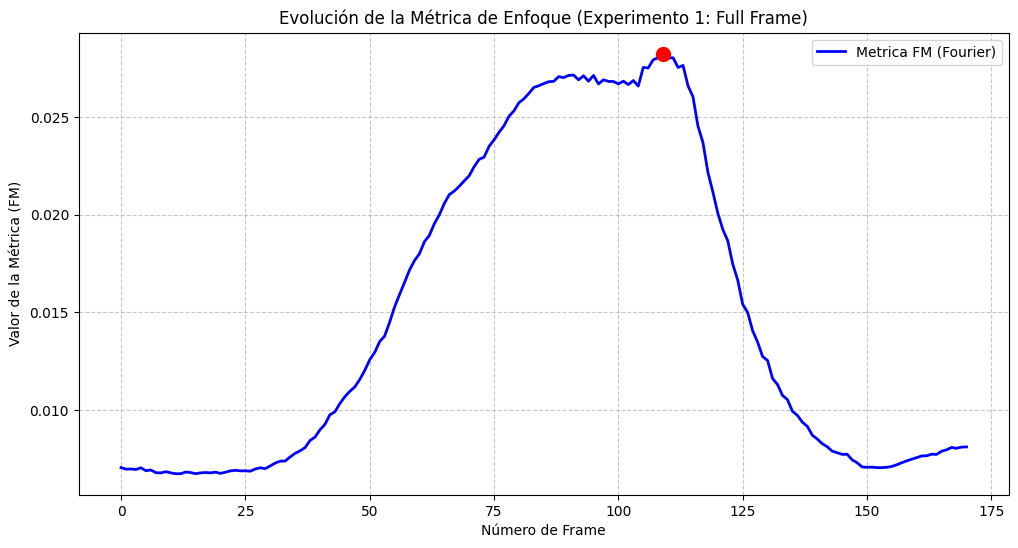

In [80]:
# Abre video
from IPython.core.pylabtools import figsize
video_path = "focus_video.mov"
# Funcion de captura de video
capture_video = cv2.VideoCapture(video_path)

f_valores_m = []

if not capture_video.isOpened():
    # Se chequea que este abierto
    print("Error to open file in video")
else:
    # Se leen todos los frames del video
    while capture_video.isOpened():
        ret, frame = capture_video.read()
        # Frame es la variable de control.
        if ret:

            # Se procede a convertir a escala de grises
            frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Se aplica la transfromada de Fourier
            f = np.fft.fft2(frame_gris)

            # Se desplaza el origen (frecuencia cero) al centro
            f_shift = np.fft.fftshift(f)

            # Se obtiene el valor absoluto (magnitud)
            af = np.abs(f_shift)

            # Se calcula el maximo de la frecuencia
            M = np.max(af)

            # Se calcula el umbral (threshold)
            thres = M / 1000

            # Se cuentan cuantos píxeles superan el umbral (TH)
            # Se usa una máscara booleana que cuenta los True
            TH = np.count_nonzero(af > thres)

            # Se calcular la métrica final FM = TH / (M * N)
            # af.size nos da el total de píxeles (M x N) automáticamente
            fm = TH / af.size

            # Se guardan el resultado
            f_valores_m.append(fm)

        else:
            break

#  Se imprimen todos los valores de f_valores_m y se ve la progresion donde obtenemos el M mayor, que nos inica la imagen mas en foco
plt.figure(figsize=(12, 6))

# Se grafican los valores de FM
plt.plot( f_valores_m, color='blue', linewidth=2, label= 'Metrica FM (Fourier)')

# Se resalta el punto maximo
max_fm = max(f_valores_m)
index_max = f_valores_m.index(max_fm)

# Se marca el punto de máximo enfoque
plt.scatter(index_max, max_fm, color='red', s=100, zorder=5)

# Se configura de histograma
plt.title('Evolución de la Métrica de Enfoque (Experimento 1: Full Frame)')
plt.xlabel('Número de Frame')
plt.ylabel('Valor de la Métrica (FM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show() 

# Descomentar par aver el area de enfoque con el percentil inidcado.
# area_enfoque(f_valores_m, 95)


### 1.2 ) Medición sobre una ROI ubicada en el centro del frame.  Area de la ROI = 5 o 10% del area total del frame.

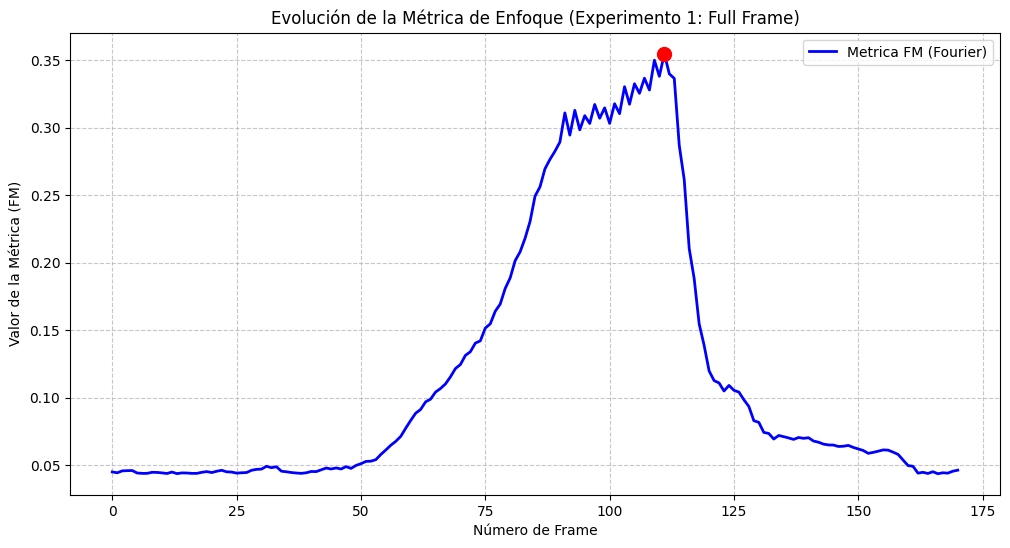

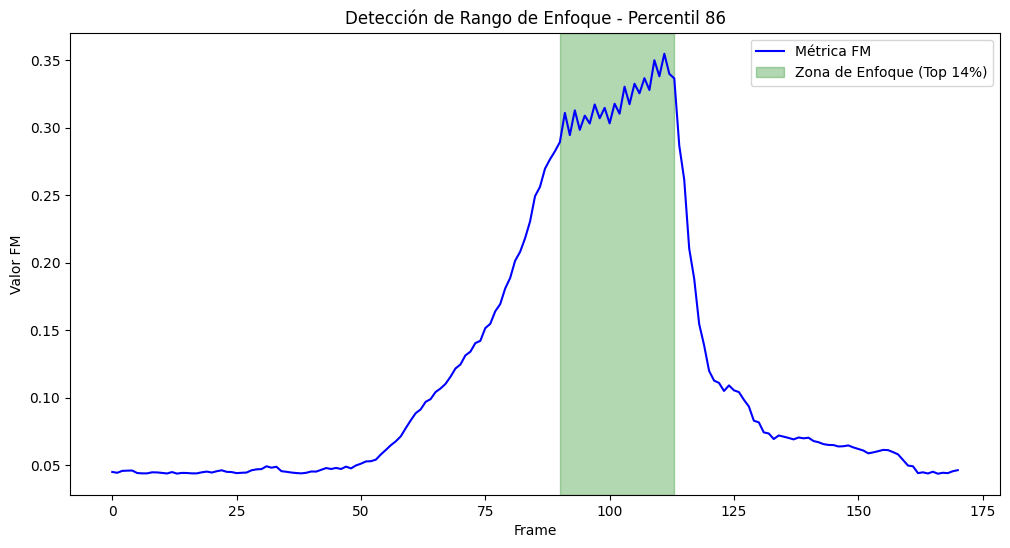

El video estuvo en foco entre los frames 90 y 113


In [81]:
# Abre video
from IPython.core.pylabtools import figsize

video_path = "focus_video.mov"
# se puede probar con el video que se generara optimizado.
# video_path = "focus_video_optimizado.avi"

# Funcion de captura de video
capture_video = cv2.VideoCapture(video_path)

f_valores_m = []


if not capture_video.isOpened():
    # Se chequea que este abierto
    print("Error to open file in video")
else:
    # Se leen todos los frames del video
    while capture_video.isOpened():
        ret, frame = capture_video.read()
        # Frame es la variable de control.
        if ret:

            # Se procede a convertir a escala de grises
            frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Se obtiene alto por ancho
            H, W = frame_gris.shape

            # Definición de la ROI (Area de interes)
            porcentaje_area = 0.10       # Representa el 10% del área total
            s = porcentaje_area ** 0.5   # Factor de escala (raíz cuadrada del área deseada)
    
            # Se calcula el ROI
            w_roi = int(W * s)
            h_roi = int(H * s)

            # Se calculan los limites
            x_inicio = (W // 2) - (w_roi // 2)
            x_fin = x_inicio + w_roi

            y_inicio = (H // 2) - (h_roi // 2)
            y_fin = y_inicio + h_roi

            # Se extrae la región
            roi = frame_gris[y_inicio:y_fin, x_inicio:x_fin]

            # Se aplica Fourier a 'roi' en lugar de 'frame_gris'
            f = np.fft.fft2(roi)

            # Se desplaza el origen (frecuencia cero) al centro
            f_shift = np.fft.fftshift(f)

            # Se obtiene el valor absoluto (magnitud)
            af = np.abs(f_shift)

            # Se calcula el maximo de la frecuencia
            M = np.max(af)

            # Se calcula el umbral (threshold)
            thres = M / 1000

            # Se cuentan cuantos píxeles superan el umbral (TH)
            # Se usa una máscara booleana que cuenta los True
            TH = np.count_nonzero(af > thres)

            # Se calcular la métrica final FM = TH / (M * N)
            # af.size nos da el total de píxeles (M x N) automáticamente
            fm = TH / af.size

            # Se guardan el resultado
            f_valores_m.append(fm)

        else:
            break

#  Se imprimen todos los valores de f_valores_m y se ve la progresion donde obtenemos el M mayor, que nos inica la imagen mas en foco
plt.figure(figsize=(12, 6))

# Se grafican los valores de FM
plt.plot( f_valores_m, color='blue', linewidth=2, label= 'Metrica FM (Fourier)')

# Se resalta el punto maximo
max_fm = max(f_valores_m)
index_max = f_valores_m.index(max_fm)

# Se marca el punto de máximo enfoque
plt.scatter(index_max, max_fm, color='red', s=100, zorder=5)

# Se configura de histograma
plt.title('Evolución de la Métrica de Enfoque (Experimento 1: Full Frame)')
plt.xlabel('Número de Frame')
plt.ylabel('Valor de la Métrica (FM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show() 
# El percentil 86 pareceria ser el rango que mejor muestra el area de enfoque
area_enfoque(f_valores_m, 86)




### Definimos un Matriz de enfoque de 2 frames, uno en foco y otro mas desenfocado.

In [ ]:
# Obtenemos el máximo global que ya calculaste antes
max_fm_video = max(f_valores_m)

# Extraer y procesar frames específicos
frames_a_mostrar = [50, 111] # Desenfocado y Enfocado

# Matriz sobre toda ROI.
def mostrar_matriz_enfoque_roi (frames_a_mostrar, max_fm_video, capture_video):
    plt.figure(figsize=(15, 7))
    for idx, num_f in enumerate(frames_a_mostrar):
        capture_video.set(cv2.CAP_PROP_POS_FRAMES, num_f)
        ret, frame = capture_video.read()
        
        if ret:
            # Se llama a la función
            resultado_3x3 = aplicar_matriz_enfoque_roi(frame, 3, max_fm_video)
            resultado_7x7 = aplicar_matriz_enfoque_roi(frame, 7, max_fm_video)
            
            plt.subplot(2, 2, idx + 1)
            plt.imshow(resultado_3x3)
            plt.title(f"Frame {num_f} - 3x3")
            plt.axis('off')

            plt.subplot(2, 2, idx + 3)
            plt.imshow(resultado_7x7)
            plt.title(f"Frame {num_f} - 7x7")
            plt.axis('off')

    plt.show()

# Matriz sobre TODA la imagen.
def mostrar_matriz_enfoque_full (frames_a_mostrar, max_fm_video, capture_video):
    for num_f in frames_a_mostrar:
        capture_video.set(cv2.CAP_PROP_POS_FRAMES, num_f)
        ret, frame = capture_video.read()
        if ret:
            # Aplicamos la función con grilla de 3x3 o 7x7
            resultado_3x3 = aplicar_matriz_enfoque(frame, 3, max_fm_video)
            resultado_7x7 = aplicar_matriz_enfoque(frame, 7, max_fm_video)
            
            # Mostrar resultados
            plt.figure(figsize=(15, 7))
            plt.subplot(1, 2, 1)
            plt.imshow(cv2.cvtColor(resultado_3x3, cv2.COLOR_BGR2RGB))
            plt.title(f"Frame {num_f} - Matriz 3x3")
            
            plt.subplot(1, 2, 2)
            plt.imshow(cv2.cvtColor(resultado_7x7, cv2.COLOR_BGR2RGB))
            plt.title(f"Frame {num_f} - Matriz 7x7")
            plt.show()

# OPCIONES PARA VISUALIZAR LA MATRIZ DE ENFOQUE 
mostrar_matriz_enfoque_roi(frames_a_mostrar, max_fm_video, capture_video)
# mostrar_matriz_enfoque_full(frames_a_mostrar, max_fm_video, capture_video)

<Figure size 1500x700 with 0 Axes>

### Aplicar unsharp masking a un rango de frames para ampliar la zona de enfoque.

In [ ]:
# Abre video
from IPython.core.pylabtools import figsize
video_path = "focus_video.mov"
# Funcion de captura de video
capture_video = cv2.VideoCapture(video_path)

f_valores_m = []

if not capture_video.isOpened():
    # Se chequea que este abierto
    print("Error to open file in video")
else:
    # Se leen todos los frames del video
    while capture_video.isOpened():
        ret, frame = capture_video.read()
        # Frame es la variable de control.
        if ret:

            # Se procede a convertir a escala de grises
            frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Se aplica la transfromada de Fourier
            f = np.fft.fft2(frame_gris)

            # Se desplaza el origen (frecuencia cero) al centro
            f_shift = np.fft.fftshift(f)

            # Se obtiene el valor absoluto (magnitud)
            af = np.abs(f_shift)

            # Se calcula el maximo de la frecuencia
            M = np.max(af)

            # Se calcula el umbral (threshold)
            thres = M / 1000

            # Se cuentan cuantos píxeles superan el umbral (TH)
            # Se usa una máscara booleana que cuenta los True
            TH = np.count_nonzero(af > thres)

            # Se calcular la métrica final FM = TH / (M * N)
            fm = TH / af.size

            # Se guardan el resultado
            f_valores_m.append(fm)

        else:
            break

# Se resalta el punto maximo
max_fm = max(f_valores_m)
index_max = f_valores_m.index(max_fm)
inicio_foco, fin_foco = area_enfoque_rangos(f_valores_m)
capture_video.set(cv2.CAP_PROP_POS_FRAMES, 0)
n_frame = 0

# Se obtienen los valores para el nuevo video
fourcc = cv2.VideoWriter_fourcc(*'avc1')
fps = capture_video.get(cv2.CAP_PROP_FPS)
width = int(capture_video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture_video.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Se crea el objeto escritor
# Se probó con distintos codecs, .avi y .mov, pero no anduvieron
# https://opencv.org/reading-and-writing-videos-using-opencv/#h-writing-a-video-in-opencv
video_out = cv2.VideoWriter('focus_video_optimizado.mp4', fourcc, fps, (width, height))

while capture_video.isOpened():
    ret, frame = capture_video.read()
    
    if not ret:
        break

    # Se verifica si el frame actual está dentro del rango de enfoque detectado
    if inicio_foco <= n_frame <= fin_foco:
        # se aplica nuestra nueva función que aplica la tecnica
        frame_procesado = aplicar_unsharp_masking(frame, k=2.5)
    else:
        # Si está fuera del rango, mantenemos el frame original
        frame_procesado = frame

    # se van guardando los frames nuevos y los enfocados dentro de un nuevo video.
    video_out.write(frame_procesado)

    # vamos agregando un frame para avanzar en el video.
    n_frame += 1

# Se cierran los videos
capture_video.release()
video_out.release()    

# ACLARACION:
# No pude hacer que se abra el video en este msimo bloque de codigo, por eso da error (por lo menos en mi equipo)
# OpenCV(4.13.0) /Users/macmini_16g/GHA-Actions-Opencv-Python/_work/opencv-python/opencv-python/opencv/modules/videoio/src/cap_images.cpp:411: error: (-215:Assertion failed) !filename_pattern.empty() in function 'CvVideoWriter_Images'
# Sigue en el bloque de abajo la comparacion de ambos video.

2026-04-05 12:27:18.501 python[21412:755675] AVF: AVAssetWriter status: Cannot Save


### Comparacion de videos

In [84]:
# ACLARACION:
# Es MUY imperceptible a la vista, pero si se comparan los valores de FM en el paso anterior se puede ver que el nuevo video esta optimizado. 

# Se abren los dos videos
cap_orig = cv2.VideoCapture("focus_video.mov") 
cap_opt = cv2.VideoCapture("focus_video_optimizado.mp4")

if not cap_orig.isOpened() or not cap_opt.isOpened():
    print("Error al abrir uno de los videos")
else:
    while True:
        # Se lee un frame de cada video
        ret1, frame1 = cap_orig.read()
        ret2, frame2 = cap_opt.read()

        # Si alguno termina, salimos del bucle
        if not ret1 or not ret2:
            break

        # Concatenamos horizontalmente
        comparacion = cv2.hconcat([frame1, frame2])
        
        # Se muestra el resultad0
        cv2.imshow('Original vs Optimizado', comparacion)

        # Esperamos 33ms para simular 30fps y permitir salida con 'q'
        if cv2.waitKey(33) & 0xFF == ord('q'):
            break
        

# Se limpia todo para que no se cuelgue el IDE.
cap_orig.release()
cap_opt.release()
cv2.destroyAllWindows()

# ACLARACION:
# Se agrega un delay para que mi computadora cierre el player (Tengo mac y sin este fix se cuelga el player abierto)
for i in range(1, 5):
    cv2.waitKey(1)